<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/GaussianMixerModel12thOct2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Gaussian Mixer Model (GMM)**
**What is GMM?**

A gaussian mixer model is a statistical model which is used to group the data into clusters. It assumes that the data comes from multiple normal distribution that are combined together

Think of it as a soft clustering technique where each data points can belong to multiple clusters with their different probabiltic value, unlike K-means clustering where a data point belongs to only on cluster

###**Why is GMM Used**
**GMM is used when**
* **When Clustering have different shape and size:** GMM can find clusters that are elliptical, circular or any other shape, while k-means cluster only handles spherical clusters
* **When Soft Clustering is needed**: It provides you a probability of belonging to each clusters, which is helpful in scenarios where customer segmentation can be implemented
* **Flexible Clustering**: It works well for overlapping clusters, where data points might not striclty belongs to one cluster

###**How does a GMM Work**
1. **Assume Gaussian Distribution**: It assumes that the data is generated from a mix of Normal distribution categories
2. **Identify the parameters**: Each normal distribution is characterized by:
    * Mean - Where the center of the cluster will lie
    * Variance/Covariance - How spread out the clusters is
    * Weights - How much features should we consider for the gaussian clusters
3. **Expecatation - Maximization (EM)**:
    * **Expectation step** - It will calculate the probabilty that each point belongs to a specific gaussian cluster (soft assignemtn to clusters)
    * **Maximization step** - Then we will adjust the parameters(mean,var/covar/weight) of each gaussian to be better fit of the data
4. **Repeat**: We have to repeat it until the parameters got stabalized or the cluster stop chaning significantly

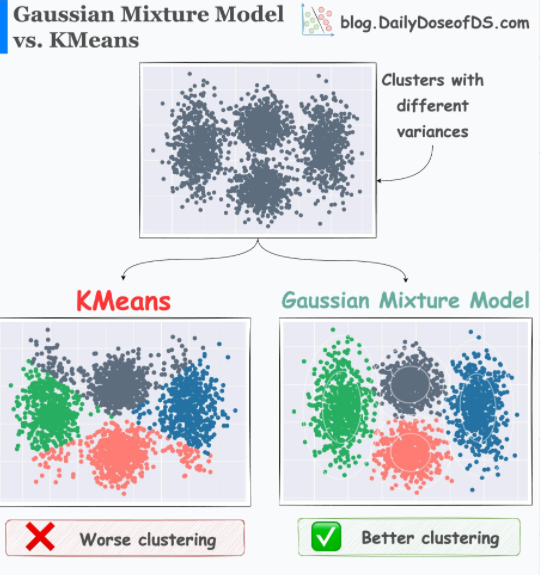

###**Advantages of GMM Over the K-Means**
1. **Soft Clustering**: GMM gives probabilities instead of hard assignment, which is more realistic for overlapping clusters
2. **Handle complex shapes**: it can model elliptical and irregular shaped clusters, unlike k-means which assumes spherical clusters
3. GMM consider both the mean value and variance of the data, which makes it more adaptable

###**Disadvantages of GMM compared to K-Means**
1. **Computational complexity**: GMM uses more resources and time because of the EM algorithm that is working on each and every data points recusrivly for one cluster at a time, espically for large dataset
2. **Sensitivity to initialization**: unlike kmeans, GMM performance can depend on the initial placement of the cluster
3. **Overfitting**: GMM might creates too many small clusters if the number of components(Gaussian Distribution) is not choosen carefully
4. **Assumption of Gaussian Distribution**: if the data does not follow a gaussain distribution, the result might not be accurate

###**Implementation of GMM**
**Import the libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Model Importing**

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

**We will create the synthetic Data**

In [ ]:
np.random.seed(42)
x,y_true = make_blobs(n_samples = 500, centers= 3, cluster_std=[1.0,2.5,0.5], random_state=42 )

In [ ]:
len(x)

500

In [ ]:
x

array([[-6.30499053e+00, -7.23169781e+00],
       [-2.10233777e+00,  1.83743252e+00],
       [ 1.01143862e+01, -4.75760294e-02],
       [-2.90130578e+00,  7.55077118e+00],
       [ 7.64291364e+00,  9.52981251e-01],
       [ 6.71571838e+00, -1.67039881e-01],
       [-5.59958492e+00, -6.92813954e+00],
       [ 5.31602090e+00,  1.84757441e+00],
       [ 1.97082776e+00,  1.61722097e+00],
       [-7.19203648e+00, -6.86706407e+00],
       [ 3.02344663e+00, -7.30700325e-01],
       [-1.35060204e+00,  8.19360381e+00],
       [-3.76164248e-01,  7.06219833e+00],
       [-1.93830711e+00,  1.01498518e+01],
       [ 5.36431598e+00,  7.16167168e+00],
       [ 7.28594005e+00, -2.42367903e+00],
       [-2.58120774e+00,  1.00178190e+01],
       [-7.44098820e+00, -6.68890472e+00],
       [-6.83848520e+00, -6.34736941e+00],
       [-3.61553260e+00,  7.81807950e+00],
       [ 1.14345990e+00,  3.38059278e+00],
       [-2.30033403e+00,  7.05461600e+00],
       [ 6.08127124e+00,  2.75129507e+00],
       [-6.

In [ ]:
y_true

array([2, 1, 1, 0, 1, 1, 2, 1, 1, 2, 1, 0, 0, 0, 1, 1, 0, 2, 2, 0, 1, 0,
       1, 2, 2, 1, 1, 2, 2, 0, 1, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 2, 2, 0, 2, 2, 1, 0, 0, 2, 1, 2, 2, 0, 1, 2, 1, 2,
       1, 2, 0, 1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 0, 2, 0, 1, 0, 2, 2, 2, 2,
       1, 0, 2, 1, 0, 1, 1, 2, 0, 0, 0, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2,
       2, 2, 2, 2, 2, 1, 0, 2, 1, 2, 0, 0, 1, 1, 2, 1, 0, 1, 2, 2, 2, 1,
       1, 2, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 0, 1, 2, 1, 1,
       0, 2, 0, 2, 1, 1, 2, 2, 0, 0, 2, 0, 0, 1, 2, 2, 2, 0, 0, 2, 2, 0,
       0, 1, 1, 1, 0, 2, 0, 0, 2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 0, 0, 2, 2, 1, 2, 1, 0, 0, 2, 2, 1, 2, 0, 0, 2, 0, 2, 0, 1,
       1, 0, 2, 0, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 2, 2, 0, 1, 0, 1, 1, 1,
       0, 0, 2, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 2, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 2, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 2, 0,
       1, 2, 1, 1, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 1,

**Building Gaussian Mixure Model**

In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmmLabels = gmm.fit_predict(x)

In [ ]:
gmmLabels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [ ]:
gmmScore = silhouette_score(x,gmmLabels)
print(f'The Accuracy of GMM: {gmmScore:.2f}')

The Accuracy of GMM: 0.77


**Let's see with kmeans**

In [ ]:
KM = KMeans(n_clusters = 3, random_state = 42)
kmLable = KM.fit_predict(x)

In [ ]:
kmLable

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 2,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       2, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 2, 0, 2, 0,

In [ ]:
KMScore = silhouette_score(x,kmLable)
print(f'The accuracy of K means: {KMScore:.2f}')

The accuracy of K means: 0.77


**The silhoutte score is coming same in both GMM and KMeans**

Let's see the visual segreggeting the clusters based on soft and hard clustering

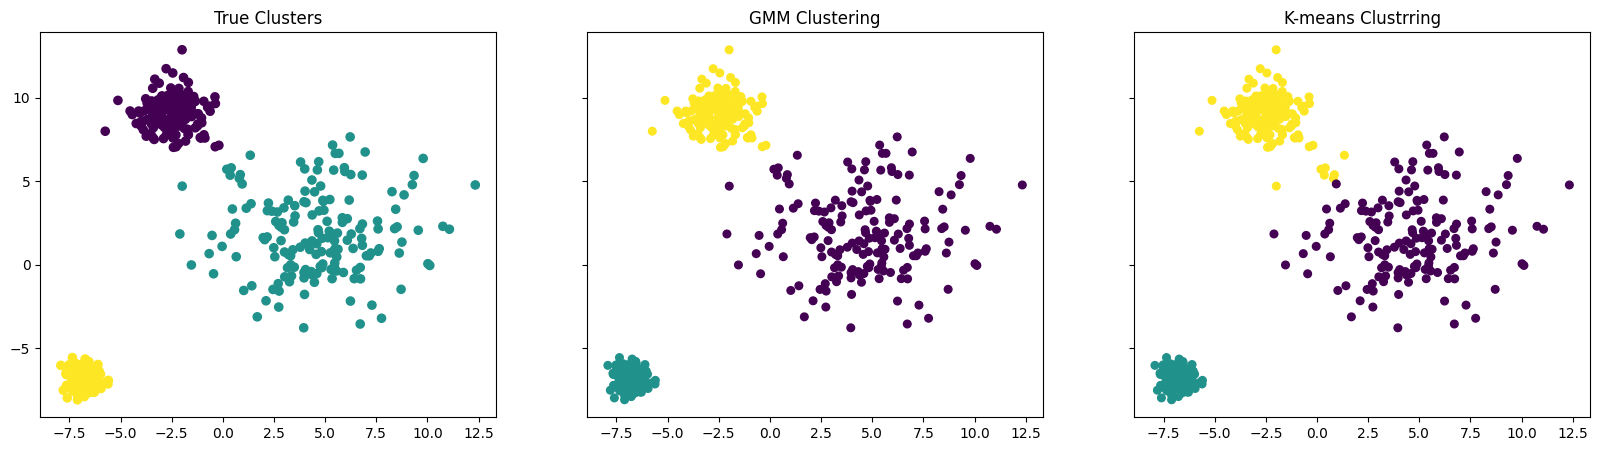

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(20,5), sharex = True, sharey = True)
axes[0].scatter(x[:,0],x[:,1], c=y_true, s= 35)
axes[0].set_title('True Clusters')

axes[1].scatter(x[:,0],x[:,1],c = gmmLabels, s = 30)
axes[1].set_title('GMM Clustering')

axes[2].scatter(x[:,0],x[:,1], c = kmLable, s = 30)
axes[2].set_title('K-means Clustrring')
plt.show()